=== Memuat Fitur dan Label ===
Sukses memuat data!
Bentuk X Awal (Semua Fitur)  : (472279, 30, 5)
Bentuk X Baru (EAR Only)     : (472279, 30, 1)
Bentuk y (Sample,)           : (472279,)

=== Distribusi Data ===
Data Latih (Train)      : (377823, 30, 1) | Label: (377823, 3)
Data Validasi (Val)     : (47228, 30, 1) | Label: (47228, 3)
Data Uji (Test)         : (47228, 30, 1) | Label: (47228, 3)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,243 (133.76 KB)

 Trainable params: 33,923 (132.51 KB)

 Non-trainable params: 320 (1.25 KB)


=== Memulai Pelatihan Model ===
Epoch 1/50
5904/5904 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3894 - loss: 1.1292
Epoch 1: val_loss improved from None to 1.03520, saving model to EAR_only_5000_frames_30_seq_best_drowsiness_lstm.keras

Epoch 1: finished saving model to EAR_only_5000_frames_30_seq_best_drowsiness_lstm.keras
5904/5904 ━━━━━━━━━━━━━━━━━━━━ 72s 12ms/step - accuracy: 0.4126 - loss: 1.0859 - val_accuracy: 0.4495 - val_loss: 1.0352 - learning_rate: 0.0010
Epoch 2/50
5904/5904 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4477 - loss: 1.0426
Epoch 2: val_loss improved from 1.03520 to 1.02921, saving model to EAR_only_5000_frames_30_seq_best_drowsiness_lstm.keras

Epoch 2: finished saving model to EAR_only_5000_frames_30_seq_best_drowsiness_lstm.keras
5904/5904 ━━━━━━━━━━━━━━━━━━━━ 70s 12ms/step - accuracy: 0.4503 - loss: 1.0408 - val_accuracy: 0.4642 - val_loss: 1.0292 - learning_rate: 0.0010
Epoch 3/50
5901/5904 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4585 - 

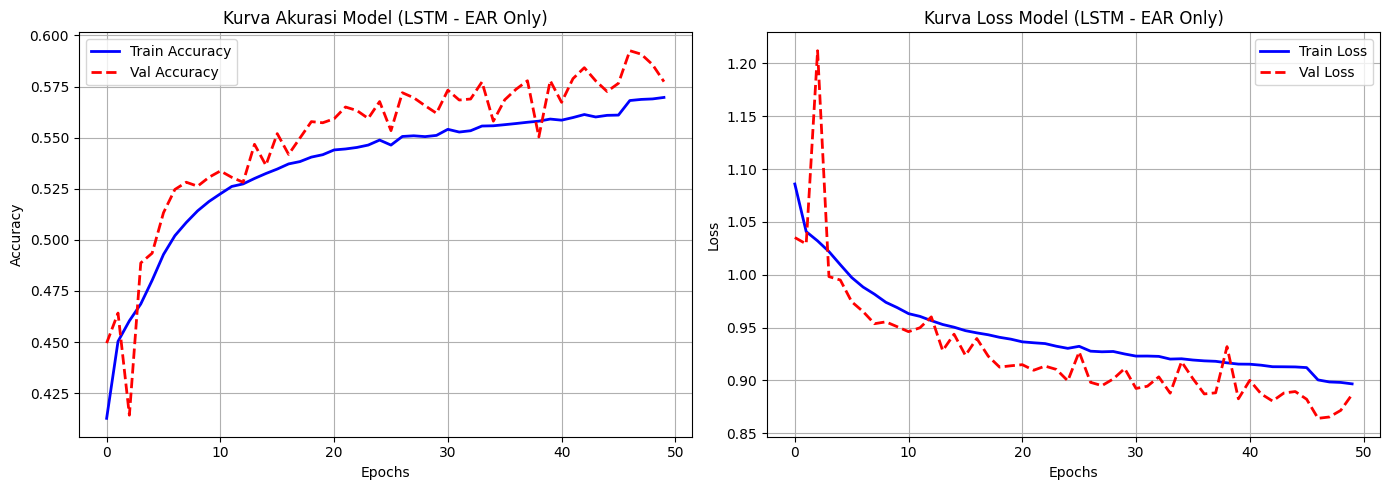

1476/1476 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

=== Classification Report ===
                  precision    recall  f1-score   support

       Alert (0)       0.55      0.75      0.63     15928
Low Vigilant (5)       0.60      0.42      0.49     15470
     Drowsy (10)       0.65      0.60      0.62     15830

        accuracy                           0.59     47228
       macro avg       0.60      0.59      0.58     47228
    weighted avg       0.60      0.59      0.58     47228



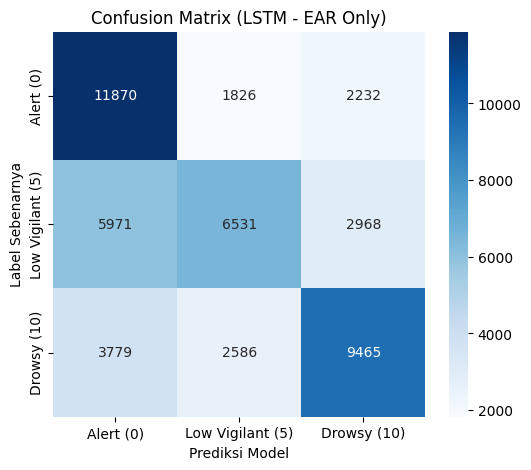

In [3]:
# Step 4 (Pembuatan & Pelatihan Model LSTM - EAR Only)
# Terdiri atas: 
#   1. Slicing Fitur (Hanya 1 Kolom EAR)
#   2. Stratified Splitting (secara aman pada label 1D)
#   3. Regularisasi L2 & Batch Normalization
#   4. Advanced Callbacks untuk mencegah overfitting

import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

# ==========================================
# 1. LOAD DATASET HASIL EKSTRAKSI STEP 3 & SLICING FITUR
# ==========================================
print("=== Memuat Fitur dan Label ===")
try:
    X_raw = np.load('/kaggle/input/datasets/adinur0611/ear-mar-features-uta-dataset-5000-frames/X_features_rldd_head_pose.npy')
    y = np.load('/kaggle/input/datasets/adinur0611/ear-mar-features-uta-dataset-5000-frames/y_labels_rldd_head_pose.npy')
    
    # PERBAIKAN: Ambil HANYA fitur EAR (Kolom 0: EAR)
    X = X_raw[:, :, :1]
    
    print(f"Sukses memuat data!")
    print(f"Bentuk X Awal (Semua Fitur)  : {X_raw.shape}")
    print(f"Bentuk X Baru (EAR Only)     : {X.shape}")
    print(f"Bentuk y (Sample,)           : {y.shape}")
except FileNotFoundError:
    print("❌ Error: File .npy tidak ditemukan di /kaggle/input/.")
    print("Pastikan file dataset sudah di-add ke notebook Anda.")
    sys.exit(1)

# ==========================================
# 2. PREPROCESSING & STRATIFIED SPLITTING
# ==========================================
# Bagi data menggunakan label mentah 1D (y) agar 'stratify' bekerja sempurna
# Pembagian data: 80% Train, 10% Validation, 10% Test
X_train, X_temp, y_train_raw, y_temp_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val_raw, y_test_raw = train_test_split(
    X_temp, y_temp_raw, test_size=0.5, random_state=42, stratify=y_temp_raw
)

# Lakukan One-Hot Encoding SETELAH data terbagi (format probabilitas matriks)
y_train = to_categorical(y_train_raw, num_classes=3)
y_val = to_categorical(y_val_raw, num_classes=3)
y_test = to_categorical(y_test_raw, num_classes=3)

print("\n=== Distribusi Data ===")
print(f"Data Latih (Train)      : {X_train.shape} | Label: {y_train.shape}")
print(f"Data Validasi (Val)     : {X_val.shape} | Label: {y_val.shape}")
print(f"Data Uji (Test)         : {X_test.shape} | Label: {y_test.shape}")

# ==========================================
# 3. MEMBANGUN ARSITEKTUR STANDARD LSTM
# ==========================================
def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        
        # Layer 1: Standard LSTM Pertama
        LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.4),
        
        # Layer 2: Standard LSTM Kedua
        LSTM(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.4),
        
        # Layer 3: Dense Layer 1
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),
        
        # Layer 4: Dense Layer 2
        Dense(32, activation='relu'),
        
        # Layer Output: Softmax Klasifikasi Multi-kelas (3 Derajat Kantuk)
        Dense(3, activation='softmax')
    ])
    
    return model

input_shape = (X_train.shape[1], X_train.shape[2]) # (30, 1)
model = build_lstm_model(input_shape)

# Kompilasi Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 4. SETTING CALLBACKS
# ==========================================
checkpoint_filename = 'EAR_only_5000_frames_30_seq_best_drowsiness_lstm.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(checkpoint_filename, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# ==========================================
# 5. PROSES TRAINING MODEL
# ==========================================
print("\n=== Memulai Pelatihan Model ===")
EPOCHS = 50
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

# ==========================================
# 6. EVALUASI DAN VISUALISASI KINERJA
# ==========================================
print("\n=== Evaluasi Akhir Model ===")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Akurasi Akhir pada Data Uji: {test_acc * 100:.2f}%")
print(f"Loss Akhir pada Data Uji   : {test_loss:.4f}")

# Plotting Loss dan Accuracy
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='b', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='r', linestyle='--', linewidth=2)
plt.title('Kurva Akurasi Model (LSTM - EAR Only)', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='b', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='r', linestyle='--', linewidth=2)
plt.title('Kurva Loss Model (LSTM - EAR Only)', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 7. MATRIKS EVALUASI LANJUTAN
# ==========================================
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

target_names = ['Alert (0)', 'Low Vigilant (5)', 'Drowsy (10)']

print("\n=== Classification Report ===")
print(classification_report(y_test_raw, y_pred_classes, target_names=target_names))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_raw, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (LSTM - EAR Only)')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Sebenarnya')
plt.show()

In [4]:
import os
from IPython.display import display, FileLink

print("=== DAFTAR MODEL TERBAIK ===")

# 1. Buat link download untuk Model Utama (EAR & MAR)
if os.path.exists('EAR_only_5000_frames_30_seq_best_drowsiness_lstm.keras'):
    print("\n✅ Klik link di bawah untuk mendownload Model LSTM Utama (EAR only):")
    display(FileLink('EAR_only_5000_frames_30_seq_best_drowsiness_lstm.keras'))
else:
    print("\n❌ File 'EAR_only_5000_frames_30_seq_best_drowsiness_lstm.keras' tidak ditemukan.")

=== DAFTAR MODEL TERBAIK ===

✅ Klik link di bawah untuk mendownload Model LSTM Utama (EAR only):


/kaggle/working/EAR_only_5000_frames_30_seq_best_drowsiness_lstm.keras

=== Memuat Fitur dan Label ===
Sukses memuat data!
Bentuk X Awal (Semua Fitur)  : (472279, 30, 5)
Bentuk X Baru (EAR + MAR)    : (472279, 30, 2)
Bentuk y (Sample,)           : (472279,)

=== Distribusi Data ===
Data Latih (Train)      : (377823, 30, 2) | Label: (377823, 3)
Data Validasi (Val)     : (47228, 30, 2) | Label: (47228, 3)
Data Uji (Test)         : (47228, 30, 2) | Label: (47228, 3)


I0000 00:00:1786446213.049408      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786446213.052373      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,499 (134.76 KB)

 Trainable params: 34,179 (133.51 KB)

 Non-trainable params: 320 (1.25 KB)


=== Memulai Pelatihan Model ===
Epoch 1/50
5903/5904 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4018 - loss: 1.1309
Epoch 1: val_loss improved from None to 1.12290, saving model to EAR_MAR_5000_frames_30_seq_best_drowsiness_lstm.keras

Epoch 1: finished saving model to EAR_MAR_5000_frames_30_seq_best_drowsiness_lstm.keras
5904/5904 ━━━━━━━━━━━━━━━━━━━━ 74s 12ms/step - accuracy: 0.4267 - loss: 1.0821 - val_accuracy: 0.3745 - val_loss: 1.1229 - learning_rate: 0.0010
Epoch 2/50
5900/5904 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4683 - loss: 1.0292
Epoch 2: val_loss improved from 1.12290 to 1.04289, saving model to EAR_MAR_5000_frames_30_seq_best_drowsiness_lstm.keras

Epoch 2: finished saving model to EAR_MAR_5000_frames_30_seq_best_drowsiness_lstm.keras
5904/5904 ━━━━━━━━━━━━━━━━━━━━ 68s 11ms/step - accuracy: 0.4745 - loss: 1.0228 - val_accuracy: 0.4449 - val_loss: 1.0429 - learning_rate: 0.0010
Epoch 3/50
5900/5904 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4897 - loss

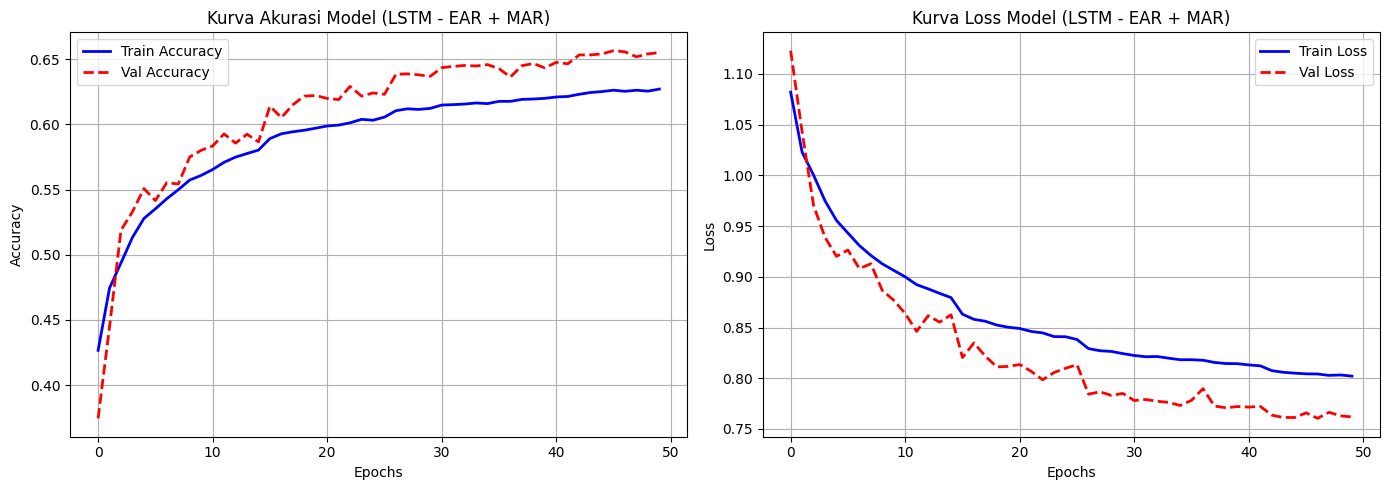

1476/1476 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

=== Classification Report ===
                  precision    recall  f1-score   support

       Alert (0)       0.64      0.76      0.69     15928
Low Vigilant (5)       0.67      0.53      0.59     15470
     Drowsy (10)       0.67      0.69      0.68     15830

        accuracy                           0.66     47228
       macro avg       0.66      0.66      0.65     47228
    weighted avg       0.66      0.66      0.65     47228



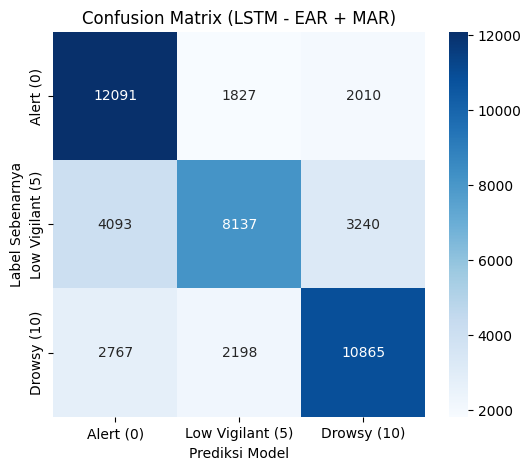

In [1]:
# Step 4 (Pembuatan & Pelatihan Model LSTM - EAR + MAR)
# Terdiri atas: 
#   1. Slicing Fitur (Mengambil 2 Kolom: EAR dan MAR)
#   2. Stratified Splitting (secara aman pada label 1D)
#   3. Regularisasi L2 & Batch Normalization
#   4. Advanced Callbacks untuk mencegah overfitting

import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

# ==========================================
# 1. LOAD DATASET HASIL EKSTRAKSI STEP 3 & SLICING FITUR
# ==========================================
print("=== Memuat Fitur dan Label ===")
try:
    X_raw = np.load('/kaggle/input/datasets/adinur0611/ear-mar-features-uta-dataset-5000-frames/X_features_rldd_head_pose.npy')
    y = np.load('/kaggle/input/datasets/adinur0611/ear-mar-features-uta-dataset-5000-frames/y_labels_rldd_head_pose.npy')
    
    # MODIFIKASI: Ambil 2 fitur pertama (Kolom 0: EAR, Kolom 1: MAR)
    X = X_raw[:, :, :2]
    
    print(f"Sukses memuat data!")
    print(f"Bentuk X Awal (Semua Fitur)  : {X_raw.shape}")
    print(f"Bentuk X Baru (EAR + MAR)    : {X.shape}")
    print(f"Bentuk y (Sample,)           : {y.shape}")
except FileNotFoundError:
    print("❌ Error: File .npy tidak ditemukan di /kaggle/input/.")
    print("Pastikan file dataset sudah di-add ke notebook Anda.")
    sys.exit(1)

# ==========================================
# 2. PREPROCESSING & STRATIFIED SPLITTING
# ==========================================
# Bagi data menggunakan label mentah 1D (y) agar 'stratify' bekerja sempurna
# Pembagian data: 80% Train, 10% Validation, 10% Test
X_train, X_temp, y_train_raw, y_temp_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val_raw, y_test_raw = train_test_split(
    X_temp, y_temp_raw, test_size=0.5, random_state=42, stratify=y_temp_raw
)

# Lakukan One-Hot Encoding SETELAH data terbagi (format probabilitas matriks)
y_train = to_categorical(y_train_raw, num_classes=3)
y_val = to_categorical(y_val_raw, num_classes=3)
y_test = to_categorical(y_test_raw, num_classes=3)

print("\n=== Distribusi Data ===")
print(f"Data Latih (Train)      : {X_train.shape} | Label: {y_train.shape}")
print(f"Data Validasi (Val)     : {X_val.shape} | Label: {y_val.shape}")
print(f"Data Uji (Test)         : {X_test.shape} | Label: {y_test.shape}")

# ==========================================
# 3. MEMBANGUN ARSITEKTUR STANDARD LSTM
# ==========================================
def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        
        # Layer 1: Standard LSTM Pertama
        LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.4),
        
        # Layer 2: Standard LSTM Kedua
        LSTM(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.4),
        
        # Layer 3: Dense Layer 1
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),
        
        # Layer 4: Dense Layer 2
        Dense(32, activation='relu'),
        
        # Layer Output: Softmax Klasifikasi Multi-kelas (3 Derajat Kantuk)
        Dense(3, activation='softmax')
    ])
    
    return model

input_shape = (X_train.shape[1], X_train.shape[2]) # (30, 2)
model = build_lstm_model(input_shape)

# Kompilasi Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 4. SETTING CALLBACKS
# ==========================================
# Nama file penyimpanan diubah menjadi khusus EAR_MAR dan LSTM
checkpoint_filename = 'EAR_MAR_5000_frames_30_seq_best_drowsiness_lstm.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(checkpoint_filename, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# ==========================================
# 5. PROSES TRAINING MODEL
# ==========================================
print("\n=== Memulai Pelatihan Model ===")
EPOCHS = 50
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

# ==========================================
# 6. EVALUASI DAN VISUALISASI KINERJA
# ==========================================
print("\n=== Evaluasi Akhir Model ===")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Akurasi Akhir pada Data Uji: {test_acc * 100:.2f}%")
print(f"Loss Akhir pada Data Uji   : {test_loss:.4f}")

# Plotting Loss dan Accuracy
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='b', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='r', linestyle='--', linewidth=2)
plt.title('Kurva Akurasi Model (LSTM - EAR + MAR)', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='b', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='r', linestyle='--', linewidth=2)
plt.title('Kurva Loss Model (LSTM - EAR + MAR)', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 7. MATRIKS EVALUASI LANJUTAN
# ==========================================
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

target_names = ['Alert (0)', 'Low Vigilant (5)', 'Drowsy (10)']

print("\n=== Classification Report ===")
print(classification_report(y_test_raw, y_pred_classes, target_names=target_names))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_raw, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (LSTM - EAR + MAR)')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Sebenarnya')
plt.show()

In [2]:
import os
from IPython.display import display, FileLink

print("=== DAFTAR MODEL TERBAIK ===")

# 1. Buat link download untuk Model Utama (EAR & MAR)
if os.path.exists('EAR_MAR_5000_frames_30_seq_best_drowsiness_lstm.keras'):
    print("\n✅ Klik link di bawah untuk mendownload Model LSTM Utama (EAR+MAR):")
    display(FileLink('EAR_MAR_5000_frames_30_seq_best_drowsiness_lstm.keras'))
else:
    print("\n❌ File 'EAR_MAR_5000_frames_30_seq_best_drowsiness_lstm.keras' tidak ditemukan.")

=== DAFTAR MODEL TERBAIK ===

✅ Klik link di bawah untuk mendownload Model LSTM Utama (EAR+MAR):


/kaggle/working/EAR_MAR_5000_frames_30_seq_best_drowsiness_lstm.keras

=== Memuat Fitur dan Label ===
Sukses memuat data!
Bentuk X Awal (Semua Fitur)  : (472279, 30, 5)
Bentuk X Baru (5 Fitur)      : (472279, 30, 5)
Bentuk y (Sample,)           : (472279,)

=== Distribusi Data ===
Data Latih (Train)      : (377823, 30, 5) | Label: (377823, 3)
Data Validasi (Val)     : (47228, 30, 5) | Label: (47228, 3)
Data Uji (Test)         : (47228, 30, 5) | Label: (47228, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,267 (137.76 KB)

 Trainable params: 34,947 (136.51 KB)

 Non-trainable params: 320 (1.25 KB)


=== Memulai Pelatihan Model ===
Epoch 1/50
5900/5904 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4568 - loss: 1.0863
Epoch 1: val_loss improved from None to 0.79610, saving model to EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_lstm.keras

Epoch 1: finished saving model to EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_lstm.keras
5904/5904 ━━━━━━━━━━━━━━━━━━━━ 72s 12ms/step - accuracy: 0.5279 - loss: 0.9835 - val_accuracy: 0.6436 - val_loss: 0.7961 - learning_rate: 0.0010
Epoch 2/50
5900/5904 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6385 - loss: 0.8254
Epoch 2: val_loss improved from 0.79610 to 0.73511, saving model to EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_lstm.keras

Epoch 2: finished saving model to EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_lstm.keras
5904/5904 ━━━━━━━━━━━━━━━━━━━━ 68s 11ms/step - accuracy: 0.6548 - loss: 0.7986 - val_accuracy: 0.6931 - val_loss: 0.7351 - learning_rate: 0.0010
Epoch 3/50
5904/5904 ━━━━━━━━━━━━━━━━━━━━ 0s

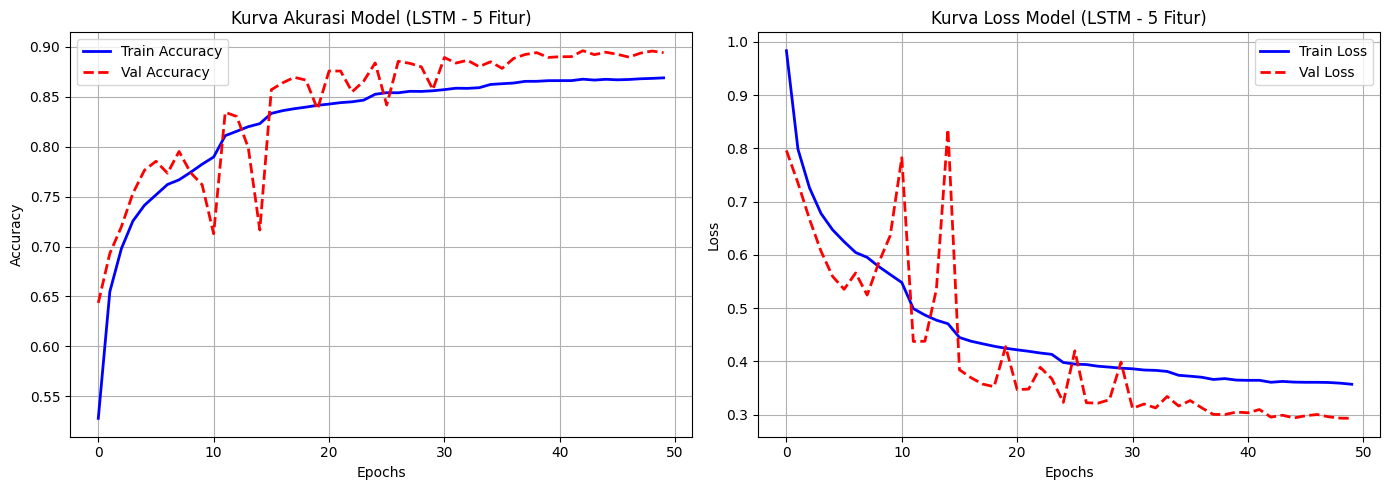

1476/1476 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

=== Classification Report ===
                  precision    recall  f1-score   support

       Alert (0)       0.87      0.91      0.89     15928
Low Vigilant (5)       0.90      0.87      0.89     15470
     Drowsy (10)       0.91      0.90      0.90     15830

        accuracy                           0.90     47228
       macro avg       0.90      0.89      0.89     47228
    weighted avg       0.90      0.90      0.90     47228



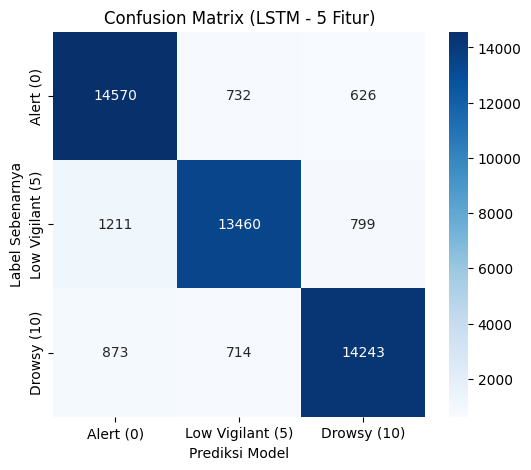

In [3]:
# Step 4 (Pembuatan & Pelatihan Model LSTM - EAR + MAR + HeadPose)
# Terdiri atas: 
#   1. Slicing Fitur (Mengambil 5 Kolom: EAR, MAR, dan 3 Head Pose)
#   2. Stratified Splitting (secara aman pada label 1D)
#   3. Regularisasi L2 & Batch Normalization
#   4. Advanced Callbacks untuk mencegah overfitting

import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

# ==========================================
# 1. LOAD DATASET HASIL EKSTRAKSI STEP 3 & SLICING FITUR
# ==========================================
print("=== Memuat Fitur dan Label ===")
try:
    X_raw = np.load('/kaggle/input/datasets/adinur0611/ear-mar-features-uta-dataset-5000-frames/X_features_rldd_head_pose.npy')
    y = np.load('/kaggle/input/datasets/adinur0611/ear-mar-features-uta-dataset-5000-frames/y_labels_rldd_head_pose.npy')
    
    # MODIFIKASI: Ambil 5 fitur (Kolom 0: EAR, 1: MAR, 2-4: Head Pose)
    X = X_raw[:, :, :5]
    
    print(f"Sukses memuat data!")
    print(f"Bentuk X Awal (Semua Fitur)  : {X_raw.shape}")
    print(f"Bentuk X Baru (5 Fitur)      : {X.shape}")
    print(f"Bentuk y (Sample,)           : {y.shape}")
except FileNotFoundError:
    print("❌ Error: File .npy tidak ditemukan di /kaggle/input/.")
    print("Pastikan file dataset sudah di-add ke notebook Anda.")
    sys.exit(1)

# ==========================================
# 2. PREPROCESSING & STRATIFIED SPLITTING
# ==========================================
# Bagi data menggunakan label mentah 1D (y) agar 'stratify' bekerja sempurna
# Pembagian data: 80% Train, 10% Validation, 10% Test
X_train, X_temp, y_train_raw, y_temp_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val_raw, y_test_raw = train_test_split(
    X_temp, y_temp_raw, test_size=0.5, random_state=42, stratify=y_temp_raw
)

# Lakukan One-Hot Encoding SETELAH data terbagi (format probabilitas matriks)
y_train = to_categorical(y_train_raw, num_classes=3)
y_val = to_categorical(y_val_raw, num_classes=3)
y_test = to_categorical(y_test_raw, num_classes=3)

print("\n=== Distribusi Data ===")
print(f"Data Latih (Train)      : {X_train.shape} | Label: {y_train.shape}")
print(f"Data Validasi (Val)     : {X_val.shape} | Label: {y_val.shape}")
print(f"Data Uji (Test)         : {X_test.shape} | Label: {y_test.shape}")

# ==========================================
# 3. MEMBANGUN ARSITEKTUR STANDARD LSTM
# ==========================================
def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        
        # Layer 1: Standard LSTM Pertama
        LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.4),
        
        # Layer 2: Standard LSTM Kedua
        LSTM(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.4),
        
        # Layer 3: Dense Layer 1
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),
        
        # Layer 4: Dense Layer 2
        Dense(32, activation='relu'),
        
        # Layer Output: Softmax Klasifikasi Multi-kelas (3 Derajat Kantuk)
        Dense(3, activation='softmax')
    ])
    
    return model

input_shape = (X_train.shape[1], X_train.shape[2]) # (30, 5)
model = build_lstm_model(input_shape)

# Kompilasi Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 4. SETTING CALLBACKS
# ==========================================
# Nama file penyimpanan diubah menjadi khusus EAR_MAR_HeadPose dan LSTM
checkpoint_filename = 'EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_lstm.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(checkpoint_filename, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# ==========================================
# 5. PROSES TRAINING MODEL
# ==========================================
print("\n=== Memulai Pelatihan Model ===")
EPOCHS = 50
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

# ==========================================
# 6. EVALUASI DAN VISUALISASI KINERJA
# ==========================================
print("\n=== Evaluasi Akhir Model ===")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Akurasi Akhir pada Data Uji: {test_acc * 100:.2f}%")
print(f"Loss Akhir pada Data Uji   : {test_loss:.4f}")

# Plotting Loss dan Accuracy
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='b', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='r', linestyle='--', linewidth=2)
plt.title('Kurva Akurasi Model (LSTM - 5 Fitur)', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='b', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='r', linestyle='--', linewidth=2)
plt.title('Kurva Loss Model (LSTM - 5 Fitur)', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 7. MATRIKS EVALUASI LANJUTAN
# ==========================================
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

target_names = ['Alert (0)', 'Low Vigilant (5)', 'Drowsy (10)']

print("\n=== Classification Report ===")
print(classification_report(y_test_raw, y_pred_classes, target_names=target_names))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_raw, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (LSTM - 5 Fitur)')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Sebenarnya')
plt.show()

In [4]:
import os
from IPython.display import display, FileLink

print("=== DAFTAR MODEL TERBAIK ===")

# Nama file model 5 fitur (EAR, MAR, HeadPose)
model_filename = 'EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_lstm.keras'

# 1. Buat link download untuk Model LSTM (5 Fitur)
if os.path.exists(model_filename):
    print("\n✅ Klik link di bawah untuk mendownload Model LSTM (5 Fitur: EAR, MAR, HeadPose):")
    display(FileLink(model_filename))
else:
    print(f"\n❌ File '{model_filename}' tidak ditemukan.")

=== DAFTAR MODEL TERBAIK ===

✅ Klik link di bawah untuk mendownload Model LSTM (5 Fitur: EAR, MAR, HeadPose):


/kaggle/working/EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_lstm.keras

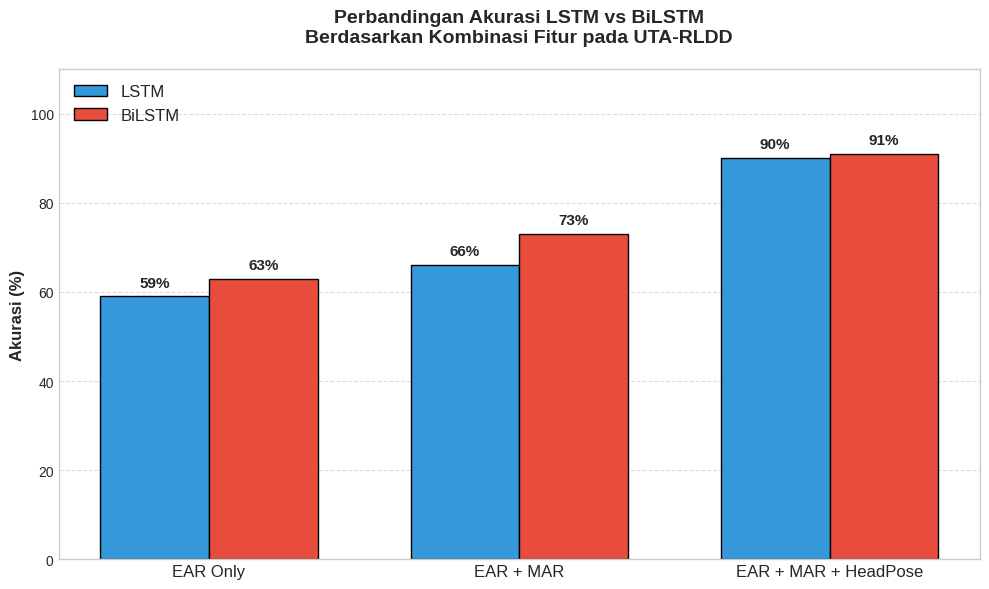

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Konfigurasi gaya grafik
plt.style.use('seaborn-v0_8-whitegrid')

# Data skenario dan nilai akurasi (dalam persentase)
skenario = ['EAR Only', 'EAR + MAR', 'EAR + MAR + HeadPose']
lstm_acc = [59, 66, 90]
bilstm_acc = [63, 73, 91]

# Pengaturan posisi sumbu X
x = np.arange(len(skenario))  
width = 0.35  # Lebar batang (bar)

# Membuat figure dan axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot batang untuk LSTM dan BiLSTM
bar1 = ax.bar(x - width/2, lstm_acc, width, label='LSTM', color='#3498db', edgecolor='black', linewidth=1)
bar2 = ax.bar(x + width/2, bilstm_acc, width, label='BiLSTM', color='#e74c3c', edgecolor='black', linewidth=1)

# Pengaturan label, judul, dan batas sumbu Y
ax.set_ylabel('Akurasi (%)', fontsize=12, fontweight='bold')
ax.set_title('Perbandingan Akurasi LSTM vs BiLSTM\nBerdasarkan Kombinasi Fitur pada UTA-RLDD', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(skenario, fontsize=12)
ax.set_ylim(0, 110) # Diberi ruang ekstra di atas agar label angka tidak terpotong

# Menambahkan grid line horizontal agar lebih mudah dibaca
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', visible=False)

# Menambahkan legenda
ax.legend(fontsize=12, loc='upper left')

# Fungsi untuk menambahkan label angka tepat di atas batang chart
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # Jarak 5 poin ke atas
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

add_labels(bar1)
add_labels(bar2)

# Mengoptimalkan layout agar rapi
plt.tight_layout()

# Menyimpan grafik sebagai file gambar resolusi tinggi (opsional untuk paper)
plt.savefig('lstm_vs_bilstm_accuracy.png', dpi=300)

# Menampilkan grafik
plt.show()